# MinHash Variety Sampling Experiments

This notebook evaluates a lexical MinHash `VarietyIndex` plugged into the existing online `trace_sampling.AdaptiveSampler`. It compares exact tool-signature clustering with MinHash over the same deterministic eventful trace stream.

The goal is not to prove that MinHash is universally better. The experiment measures the tradeoff between cross-concept separation and within-concept fragmentation, while exercising TTL purge, fallback, cache deduplication, Jaccard calibration, and decision latency.

In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT=Path.cwd()
if not (ROOT/'minhash_sampling').exists(): raise RuntimeError('Run from repository root')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from minhash_sampling import run_minhash_experiment, sweep_minhash_experiments, save_experiment_result, save_experiment_sweep
OUT=ROOT/'outputs_minhash_sampling'; OUT.mkdir(exist_ok=True)

## 1. Baseline configuration

The baseline uses 3-grams, 128 permutations, similarity threshold 0.5, and a 60-second TTL. Exact and MinHash arms keep the same deterministic stream so clustering diagnostics are directly comparable.

In [2]:
baseline=run_minhash_experiment(ngram_size=3,permutations=128,threshold=.5)
save_experiment_result(OUT/'baseline.json',baseline)
baseline_df=pd.DataFrame([baseline.to_dict()['exact'],baseline.to_dict()['minhash']],index=['exact','minhash'])
baseline_df[['concept_coverage','ari','v_measure','pair_separation_accuracy','cluster_purity','cluster_count','clusters_per_concept_mean','decision_latency_ms_p95']]

,concept_coverage,ari,v_measure,pair_separation_accuracy,cluster_purity,cluster_count,clusters_per_concept_mean,decision_latency_ms_p95
exact,1.0,0.533930,0.771307,0.783251,0.758621,4,1.25,0.0214
minhash,1.0,0.298689,0.672231,0.795567,1.000000,16,4.00,0.4575


In [3]:
baseline.to_dict()['telemetry']

{'minhash_index': {'builds': 16,
  'cache_hits': 12,
  'comparisons': 127,
  'clusters': 15,
  'purges': 11,
  'evictions': 0,
  'fallbacks': 1,
  'truncations': 0,
  'live_clusters': 4},
 'signature_provider': {'builds': 16, 'hits': 121, 'truncations': 0}}

### Baseline interpretation

The baseline MinHash configuration improves purity and pair separation, but creates many more clusters per concept. ARI and V-measure decline because those metrics penalize over-fragmentation. This is a genuine tradeoff, not a win/loss boolean.

## 2. Parameter sweep

Sweep n-grams `{2,3,4}`, permutations `{64,128}`, and thresholds `{0.3,0.5,0.7}`. Wall-clock latency varies slightly between executions; quality and telemetry counts are deterministic.

In [4]:
sweep=sweep_minhash_experiments()
save_experiment_sweep(OUT/'sweep.json',sweep)
rows=[]
for result in sweep:
 d=result.to_dict(); m=d['minhash']
 rows.append({'ngram_size':d['config']['ngram_size'],'permutations':d['config']['permutations'],'threshold':d['config']['similarity_threshold'],'separation_gain':d['separation_gain'],'purity_gain':d['purity_gain'],'ari':m['ari'],'v_measure':m['v_measure'],'cluster_purity':m['cluster_purity'],'clusters_per_concept':m['clusters_per_concept_mean'],'jaccard_mae':d['signature_jaccard_mae'],'decision_p95_ms':m['decision_latency_ms_p95'],'purges':d['telemetry']['minhash_index']['purges'],'fallbacks':d['telemetry']['minhash_index']['fallbacks']})
sweep_df=pd.DataFrame(rows)
sweep_df.sort_values(['separation_gain','purity_gain','clusters_per_concept'],ascending=[False,False,True]).head(10)

,ngram_size,permutations,threshold,separation_gain,purity_gain,ari,v_measure,cluster_purity,clusters_per_concept,jaccard_mae,decision_p95_ms,purges,fallbacks
12,4,64,0.3,0.108374,0.241379,0.678346,0.820005,1.000000,2.25,0.029181,0.2255,6,1
3,2,128,0.3,0.049261,0.172414,0.481384,0.702912,0.931034,3.00,0.019086,0.4760,6,1
0,2,64,0.3,0.046798,0.172414,0.520456,0.703826,0.931034,2.75,0.022613,0.2747,6,1
4,2,128,0.5,0.041872,0.241379,0.427533,0.699999,1.000000,3.75,0.019086,0.4465,10,1
1,2,64,0.5,0.024631,0.241379,0.353846,0.681147,1.000000,4.00,0.022613,0.2729,11,1
15,4,128,0.3,0.019704,0.137931,0.427059,0.696089,0.896552,2.50,0.019758,0.3661,6,1
7,3,64,0.5,0.017241,0.206897,0.341885,0.664044,0.965517,3.75,0.078220,0.3108,10,1
10,3,128,0.5,0.012315,0.241379,0.298689,0.672231,1.000000,4.00,0.029032,0.4234,11,1
13,4,64,0.5,0.012315,0.241379,0.298689,0.672231,1.000000,4.00,0.029181,0.2321,11,1
16,4,128,0.5,0.012315,0.241379,0.298689,0.672231,1.000000,4.00,0.019758,0.4219,11,1


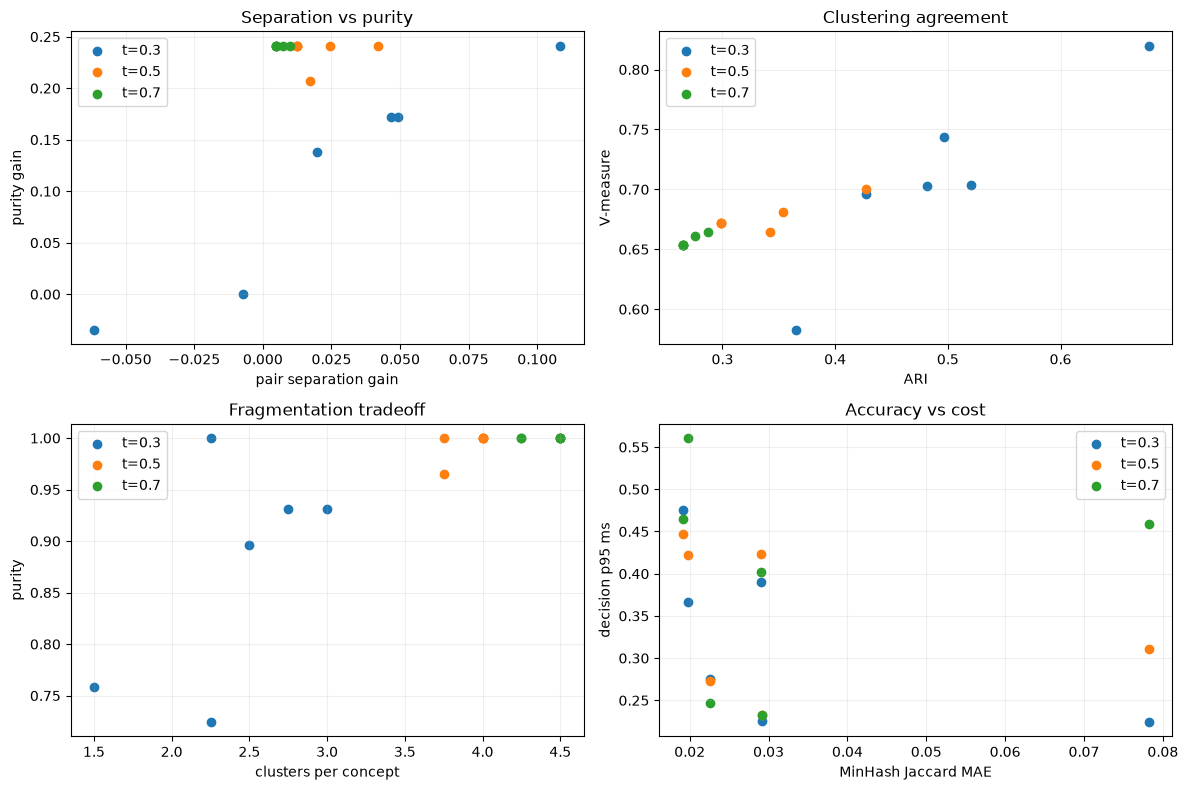

In [5]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
for threshold,group in sweep_df.groupby('threshold'):
 axes[0,0].scatter(group.separation_gain,group.purity_gain,label=f't={threshold}')
 axes[0,1].scatter(group.ari,group.v_measure,label=f't={threshold}')
 axes[1,0].scatter(group.clusters_per_concept,group.cluster_purity,label=f't={threshold}')
 axes[1,1].scatter(group.jaccard_mae,group.decision_p95_ms,label=f't={threshold}')
axes[0,0].set(xlabel='pair separation gain',ylabel='purity gain',title='Separation vs purity')
axes[0,1].set(xlabel='ARI',ylabel='V-measure',title='Clustering agreement')
axes[1,0].set(xlabel='clusters per concept',ylabel='purity',title='Fragmentation tradeoff')
axes[1,1].set(xlabel='MinHash Jaccard MAE',ylabel='decision p95 ms',title='Accuracy vs cost')
for ax in axes.ravel(): ax.legend(); ax.grid(alpha=.2)
fig.tight_layout(); plt.show()

## 3. Calibrated result

For this synthetic stream, 4-grams / 64 permutations / threshold 0.3 gives the strongest measured balance: better pair separation and purity than exact signatures while also improving ARI and V-measure, with low measured latency.

This is not a production default. MinHash is lexical rather than semantic, and thresholds must be calibrated on representative Agent 365 traffic. Always report fragmentation, TTL behavior, fallback counts, Jaccard estimation error, and latency alongside purity or coverage claims.

In [6]:
best=sweep_df.sort_values(['separation_gain','purity_gain','clusters_per_concept'],ascending=[False,False,True]).iloc[0]
best.to_dict()

{'ngram_size': 4.0,
 'permutations': 64.0,
 'threshold': 0.3,
 'separation_gain': 0.10837438423645318,
 'purity_gain': 0.24137931034482762,
 'ari': 0.6783463574489539,
 'v_measure': 0.8200045203832363,
 'cluster_purity': 1.0,
 'clusters_per_concept': 2.25,
 'jaccard_mae': 0.0291810812644146,
 'decision_p95_ms': 0.2255,
 'purges': 6.0,
 'fallbacks': 1.0}